In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from tqdm.notebook import tqdm
import albumentations as A
import cv2
from tqdm.notebook import tqdm
import shutil
from collections import Counter

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

There was a problem when trying to write in your cache folder (/root/.cache/huggingface/hub). You should set the environment variable TRANSFORMERS_CACHE to a writable directory.


Using device: cuda:7


In [2]:
DATA_DIR = 'dataset/images'  
METADATA_PATH = 'dataset/GroundTruth.csv' 

df = pd.read_csv(METADATA_PATH)

print("\nDataset Info:")
print(f"Total images: {len(df)}")
print("\nClass distribution:")
class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
for col in class_columns:
    print(f"{col}: {df[col].sum()}")

print("\nSample of metadata:")
print(df.head())


Dataset Info:
Total images: 10015

Class distribution:
MEL: 1113.0
NV: 6705.0
BCC: 514.0
AKIEC: 327.0
BKL: 1099.0
DF: 115.0
VASC: 142.0

Sample of metadata:
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [3]:
classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Calculate required augmentations for each class
TARGET_SAMPLES = 2000  # Target number of samples per class (except NV)
augment_multipliers = {}
for cls in classes:
    if cls != 'NV':  # Don't augment NV class as it has enough samples
        current_samples = df[cls].sum()
        if current_samples < TARGET_SAMPLES:
            multiplier = int(np.ceil(TARGET_SAMPLES / current_samples))
            augment_multipliers[cls] = multiplier
            print(f"Class {cls}: Need to generate {multiplier}x samples")

Class MEL: Need to generate 2x samples
Class BCC: Need to generate 4x samples
Class AKIEC: Need to generate 7x samples
Class BKL: Need to generate 2x samples
Class DF: Need to generate 18x samples
Class VASC: Need to generate 15x samples


In [4]:
augmentation = A.Compose([
    A.Rotate(limit=45, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),
    A.GaussNoise(p=0.3),
    A.Blur(blur_limit=3, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomResizedCrop(height=224, width=224, scale=(0.8, 1.0), p=0.5),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
        A.ElasticTransform(p=0.1),
    ], p=0.3),
])


In [8]:
def augment_image(image_path, num_augmentations):
    """
    Augment an image with specified number of augmentations
    """
    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    augmented_images = []
    for _ in range(num_augmentations):
        augmented = augmentation(image=image)['image']
        augmented_images.append(augmented)
    
    return augmented_images

def augment_class_data(df, class_name, multiplier, image_dir):
    """
    Augment data for a specific class
    """
    # Get samples of the class
    class_samples = df[df[class_name] == 1].copy()
    augmented_data = []
    
    print(f"Augmenting class {class_name}...")
    for idx, row in tqdm(class_samples.iterrows(), total=len(class_samples)):
        image_path = f"{image_dir}/{row['image']}.jpg"
        
        # Number of augmentations needed per image
        num_aug = multiplier - 1
        if num_aug > 0:
            augmented_images = augment_image(image_path, num_aug)
            
            # Create copy of row for each augmented image
            for i, _ in enumerate(augmented_images):
                new_row = row.copy()
                new_row['image'] = f"{row['image']}_aug_{i+1}"
                augmented_data.append(new_row)
    
    return pd.DataFrame(augmented_data)

def save_augmented_data(augmented_df, original_image_dir, output_image_dir):
    """
    Save augmented images and new DataFrame
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_image_dir, exist_ok=True)
    
    # Copy original images
    for idx, row in tqdm(df.iterrows(), desc="Copying original images"):
        src_path = f"{original_image_dir}/{row['image']}.jpg"
        dst_path = f"{output_image_dir}/{row['image']}.jpg"
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)
    
    # Save augmented images
    new_images = augmented_df[~augmented_df['image'].isin(df['image'])]
    for idx, row in tqdm(new_images.iterrows(), desc="Saving augmented images"):
        original_img_name = row['image'].split('_aug_')[0]
        img = augment_image(f"{original_image_dir}/{original_img_name}.jpg", 1)[0]
        cv2.imwrite(f"{output_image_dir}/{row['image']}.jpg", 
                   cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    
    # Save new DataFrame
    augmented_df.to_csv('augmented_metadata.csv', index=False)

In [9]:
augment_multipliers

{'MEL': 2, 'BCC': 4, 'AKIEC': 7, 'BKL': 2, 'DF': 18, 'VASC': 15}

In [10]:
augmented_df = df.copy()
for cls, multiplier in augment_multipliers.items():
    aug_class_df = augment_class_data(df, cls, multiplier, DATA_DIR)
    augmented_df = pd.concat([augmented_df, aug_class_df], ignore_index=True)

Augmenting class MEL...


  0%|          | 0/1113 [00:00<?, ?it/s]

Augmenting class BCC...


  0%|          | 0/514 [00:00<?, ?it/s]

Augmenting class AKIEC...


...

  0%|          | 0/1099 [00:00<?, ?it/s]

Augmenting class DF...


  0%|          | 0/115 [00:00<?, ?it/s]

Augmenting class VASC...


  0%|          | 0/142 [00:00<?, ?it/s]

In [5]:
save_augmented_data(augmented_df, DATA_DIR, 'dataset_aug')

print("\nClass distribution after augmentation:")
for cls in classes:
    print(f"{cls}: {augmented_df[cls].sum()}")

NameError: name 'save_augmented_data' is not defined


Augmentation examples for class: MEL


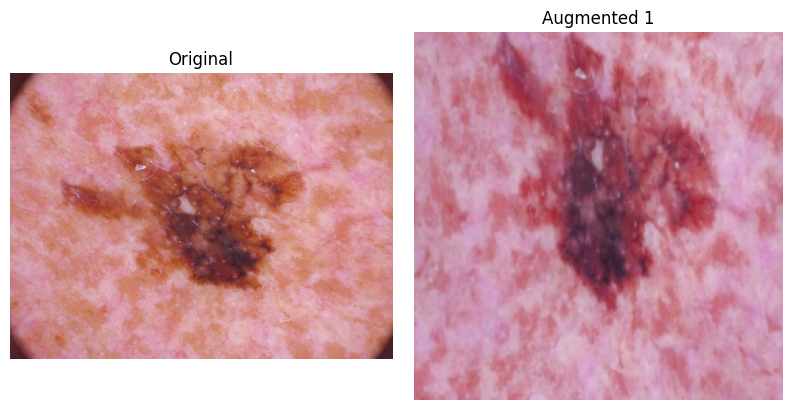


Augmentation examples for class: BCC


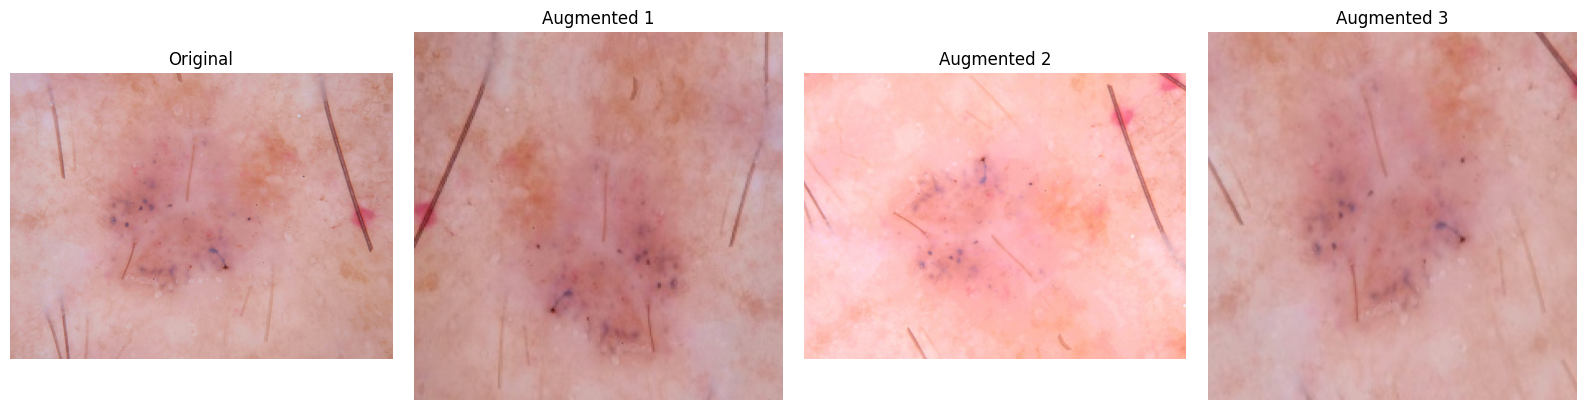


Augmentation examples for class: AKIEC


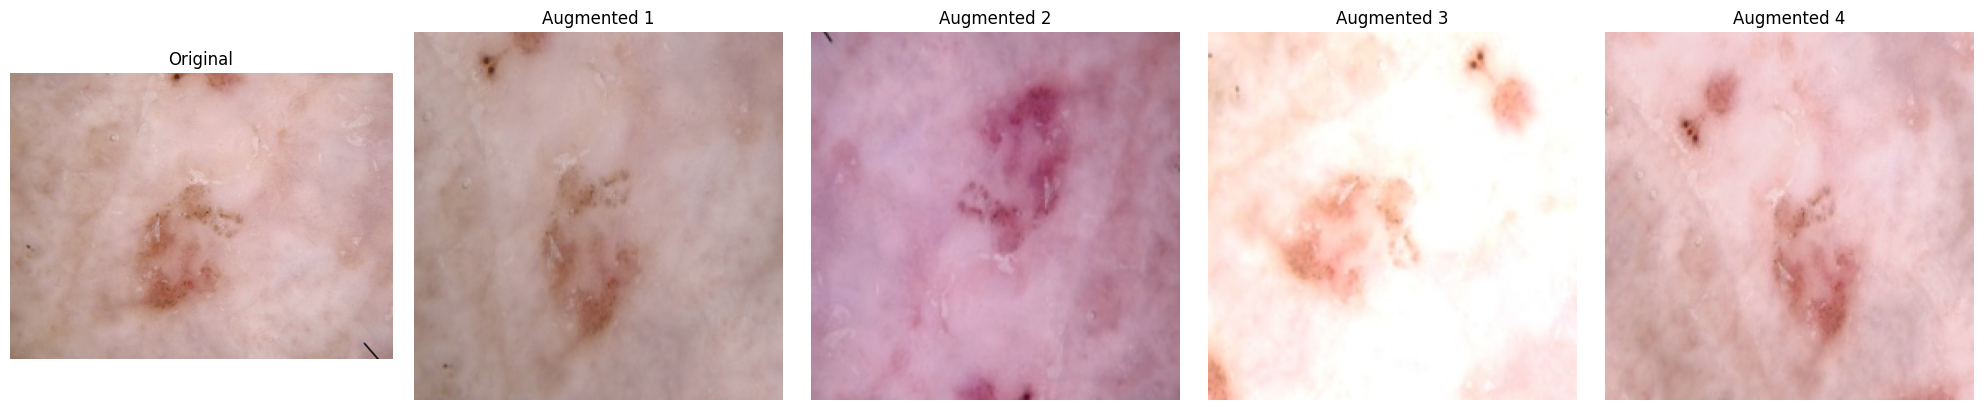


Augmentation examples for class: BKL


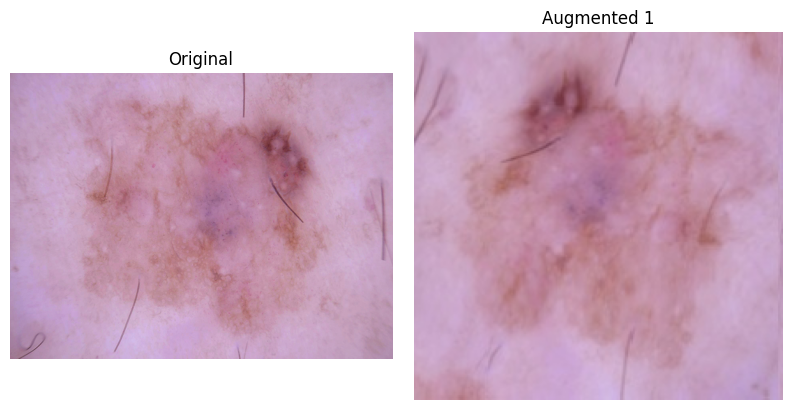


Augmentation examples for class: DF


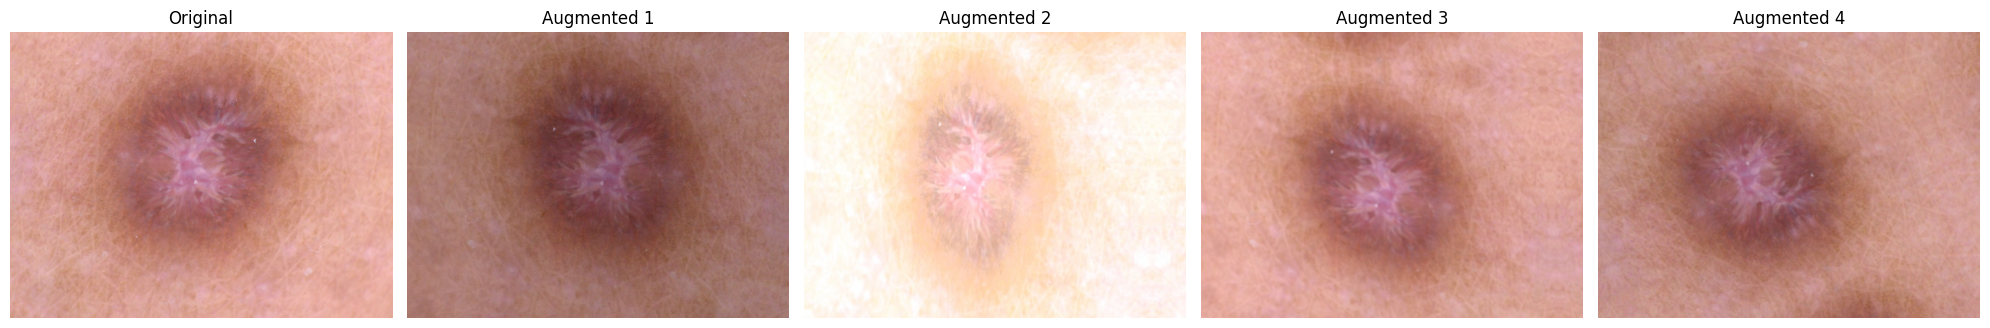


Augmentation examples for class: VASC


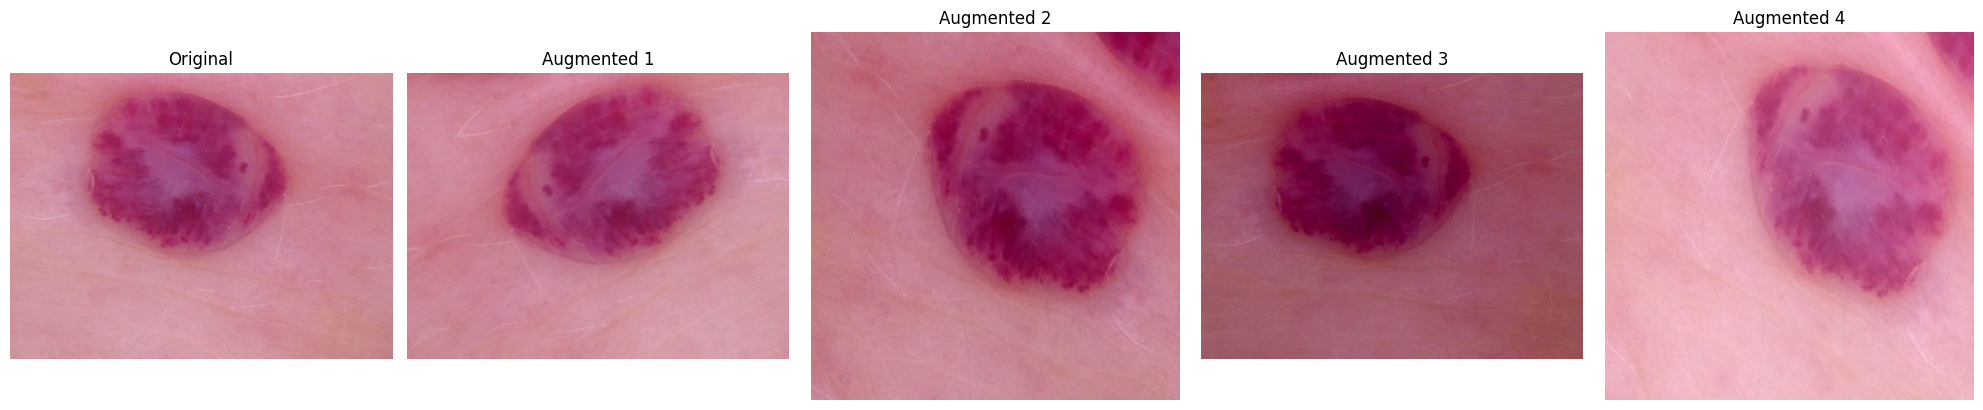

In [3]:


def show_original_and_augmented(original_img_name, augmented_df, output_image_dir, num_examples=4):
    """
    Display original image and its augmented versions
    
    Args:
        original_img_name: Name of the original image without extension
        augmented_df: DataFrame containing all image information
        output_image_dir: Directory containing all images
        num_examples: Number of augmented examples to show
    """
    # Find all augmented versions of this image
    augmented_names = augmented_df[augmented_df['image'].str.startswith(original_img_name + '_aug_')]['image']
    
    # Create figure
    plt.figure(figsize=(20, 4))
    
    # Show original image
    original_path = os.path.join(output_image_dir, f"{original_img_name}.jpg")
    original_img = cv2.imread(original_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, num_examples + 1, 1)
    plt.imshow(original_img)
    plt.title('Original')
    plt.axis('off')
    
    # Show augmented versions
    for i, aug_name in enumerate(list(augmented_names)[:num_examples]):
        aug_path = os.path.join(output_image_dir, f"{aug_name}.jpg")
        aug_img = cv2.imread(aug_path)
        aug_img = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_examples + 1, i + 2)
        plt.imshow(aug_img)
        plt.title(f'Augmented {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def show_augmented_examples_per_class(df, augmented_df, output_image_dir, classes):
    """
    Show augmentation examples for each class
    """
    for cls in classes:
        # Get one sample from the class
        original_sample = df[df[cls] == 1].iloc[0]
        print(f"\nAugmentation examples for class: {cls}")
        show_original_and_augmented(original_sample['image'], augmented_df, output_image_dir)


output_image_dir = 'dataset_aug'
augmented_df = pd.read_csv('augmented_metadata.csv')
original_df = pd.read_csv('dataset/GroundTruth.csv')
classes = ['MEL', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Show examples for each class
show_augmented_examples_per_class(original_df, augmented_df, output_image_dir, classes)

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def group_original_and_augmented(df):
    """
    Group original images with their augmented versions
    Returns a dictionary where key is original image name and value is list of all related images
    """
    image_groups = {}
    
    for idx, row in df.iterrows():
        img_name = row['image']
        # If this is augmented image (contains '_aug_')
        if '_aug_' in img_name:
            original_name = img_name.split('_aug_')[0]
            if original_name not in image_groups:
                image_groups[original_name] = []
            image_groups[original_name].append(img_name)
        else:
            # This is original image
            if img_name not in image_groups:
                image_groups[img_name] = []
            image_groups[img_name].append(img_name)
    
    return image_groups

def split_maintaining_groups(df, image_groups, test_size=0.2, random_state=42):
    """
    Split data while keeping original and augmented images together
    """
    # Get list of original images
    original_images = list(image_groups.keys())
    
    # Split original images
    train_originals, test_originals = train_test_split(
        original_images, 
        test_size=test_size, 
        random_state=random_state,
        stratify=df[df['image'].isin(original_images)][['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']].values
    )
    
    # Get all related images for each split
    train_images = []
    test_images = []
    
    for orig in train_originals:
        train_images.extend(image_groups[orig])
    for orig in test_originals:
        test_images.extend(image_groups[orig])
    
    # Create train and test DataFrames
    train_df = df[df['image'].isin(train_images)].copy()
    test_df = df[df['image'].isin(test_images)].copy()
    
    return train_df, test_df

def print_split_statistics(train_df, test_df):
    """
    Print statistics about the split
    """
    classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
    
    print("\nTrain set distribution:")
    for cls in classes:
        total = train_df[cls].sum()
        orig = train_df[~train_df['image'].str.contains('_aug_', na=False)][cls].sum()
        aug = train_df[train_df['image'].str.contains('_aug_', na=False)][cls].sum()
        print(f"{cls}: Total={total} (Original={orig}, Augmented={aug})")
    
    print("\nTest set distribution:")
    for cls in classes:
        total = test_df[cls].sum()
        orig = test_df[~test_df['image'].str.contains('_aug_', na=False)][cls].sum()
        aug = test_df[test_df['image'].str.contains('_aug_', na=False)][cls].sum()
        print(f"{cls}: Total={total} (Original={orig}, Augmented={aug})")

# Load augmented dataset
df = pd.read_csv('augmented_metadata.csv')

# Group original and augmented images
image_groups = group_original_and_augmented(df)

# Split data
train_df, test_df = split_maintaining_groups(df, image_groups, test_size=0.2)

# Print statistics
print_split_statistics(train_df, test_df)

# Save splits
train_df.to_csv('train_metadata.csv', index=False)
test_df.to_csv('test_metadata.csv', index=False)


Train set distribution:
MEL: Total=1780.0 (Original=890.0, Augmented=890.0)
NV: Total=5364.0 (Original=5364.0, Augmented=0.0)
BCC: Total=1644.0 (Original=411.0, Augmented=1233.0)
AKIEC: Total=1834.0 (Original=262.0, Augmented=1572.0)
BKL: Total=1758.0 (Original=879.0, Augmented=879.0)
DF: Total=1656.0 (Original=92.0, Augmented=1564.0)
VASC: Total=1710.0 (Original=114.0, Augmented=1596.0)

Test set distribution:
MEL: Total=446.0 (Original=223.0, Augmented=223.0)
NV: Total=1341.0 (Original=1341.0, Augmented=0.0)
BCC: Total=412.0 (Original=103.0, Augmented=309.0)
AKIEC: Total=455.0 (Original=65.0, Augmented=390.0)
BKL: Total=440.0 (Original=220.0, Augmented=220.0)
DF: Total=414.0 (Original=23.0, Augmented=391.0)
VASC: Total=420.0 (Original=28.0, Augmented=392.0)


In [5]:
class HAM10000Dataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
        self.class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image path
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(self.image_dir, img_name + '.jpg')
        
        # Get label as class index
        label_onehot = self.df.iloc[idx][self.class_columns].values.astype(np.float32)
        label = np.argmax(label_onehot)  # Convert one-hot to index
        
        # Load and transform image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
# Load splits
train_df = pd.read_csv('train_metadata.csv')
test_df = pd.read_csv('test_metadata.csv')

# Create datasets
train_dataset = HAM10000Dataset(train_df, 'dataset_aug', transform=train_transform)
test_dataset = HAM10000Dataset(test_df, 'dataset_aug', transform=test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [8]:
class SkinLesionModel(nn.Module):
    def __init__(self, num_classes=7):
        super(SkinLesionModel, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)  # Remove sigmoid, as we'll use CrossEntropyLoss
        )
    
    def forward(self, x):
        return self.resnet(x)

# Initialize model
model = SkinLesionModel().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

/opt/miniconda/envs/3d/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda/envs/3d/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [10]:
def calculate_metrics(model, data_loader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Calculating metrics'):
            images = images.to(device)
            outputs = model(images)
            _, predictions = outputs.max(1)  # Get the predicted class index
            
            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())
    
    all_labels = torch.cat(all_labels, dim=0)
    all_predictions = torch.cat(all_predictions, dim=0)
    
    # Calculate per-class accuracy
    n_classes = 7  # Number of classes
    class_correct = torch.zeros(n_classes)
    class_total = torch.zeros(n_classes)
    
    for i in range(n_classes):
        mask = (all_labels == i)
        class_correct[i] = (all_predictions[mask] == i).sum().float()
        class_total[i] = mask.sum().float()
    
    class_accuracy = class_correct / class_total
    
    classes = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
    print("\nPer-class accuracy:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {class_accuracy[i]*100:.2f}%")
    
    return class_accuracy

In [11]:
# Training loop
num_epochs = 50
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
best_val_acc = 0.0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, test_loader, criterion, device)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
        }, 'best_model.pth')
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch results
    print(f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%')
    
    # Calculate per-class metrics every 5 epochs
    if (epoch + 1) % 5 == 0:
        calculate_metrics(model, test_loader, device)


Epoch 1/50


Training:   0%|          | 0/124 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Train Loss: 0.9526 Train Acc: 66.05%
Val Loss: 1.6379 Val Acc: 53.62%

Epoch 2/50


Training:   0%|          | 0/124 [00:00<?, ?it/s]

...

Training:   0%|          | 0/124 [00:00<?, ?it/s]

Validation:   0%|          | 0/31 [00:00<?, ?it/s]

Train Loss: 0.2969 Train Acc: 90.53%
Val Loss: 0.5969 Val Acc: 81.72%


Calculating metrics:   0%|          | 0/31 [00:00<?, ?it/s]


Per-class accuracy:
MEL: 62.56%
NV: 94.18%
BCC: 84.22%
AKIEC: 64.84%
BKL: 61.36%
DF: 83.09%
VASC: 98.10%
